Iris Flower Dataset

Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Classes:
['setosa' 'versicolor' 'virginica']

Number of samples: 150

Training samples: 120
Testing samples: 30

K value: 5

KNN CLASSIFICATION RESULTS

Accuracy: 100.0 %

Actual vs Predicted:
Actual: versicolor 	Predicted: versicolor
Actual: setosa 	Predicted: setosa
Actual: virginica 	Predicted: virginica
Actual: versicolor 	Predicted: versicolor
Actual: versicolor 	Predicted: versicolor
Actual: setosa 	Predicted: setosa
Actual: versicolor 	Predicted: versicolor
Actual: virginica 	Predicted: virginica
Actual: versicolor 	Predicted: versicolor
Actual: versicolor 	Predicted: versicolor
Actual: virginica 	Predicted: virginica
Actual: setosa 	Predicted: setosa
Actual: setosa 	Predicted: setosa
Actual: setosa 	Predicted: setosa
Actual: setosa 	Predicted: setosa
Actual: versicolor 	Predicted: versicolor
Actual: virginica 	Predicted: virginica
Actual: versicolor 	Predicted: ver

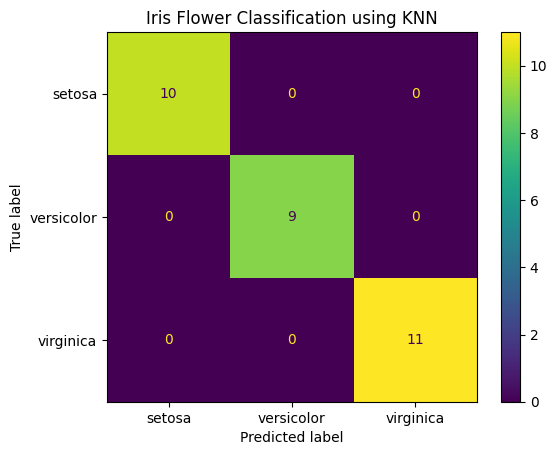


New Flower:
[[5.1 3.5 1.4 0.2]]

Predicted Flower Class:
setosa


In [ ]:
# Experiment 12: Iris Flower Classification using KNN
# Aim: Implement K-Nearest Neighbours (KNN) algorithm
#      for Iris flower classification.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


# ---------------------------------------------------------
# STEP 1: Load the Iris dataset
# ---------------------------------------------------------

iris = load_iris()

X = iris.data
y = iris.target

print("Iris Flower Dataset")
print("=" * 50)

print("\nFeatures:")
print(iris.feature_names)

print("\nClasses:")
print(iris.target_names)

print("\nNumber of samples:", len(X))


# ---------------------------------------------------------
# STEP 2: Split the dataset
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ---------------------------------------------------------
# STEP 3: Calculate Euclidean Distance
# ---------------------------------------------------------

def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))


# ---------------------------------------------------------
# STEP 4: Implement KNN manually
# ---------------------------------------------------------

def knn_predict(X_train, y_train, X_test, k=5):

    predictions = []

    for test_sample in X_test:

        distances = []

        # Calculate distance from test sample
        # to every training sample
        for i, train_sample in enumerate(X_train):

            distance = euclidean_distance(
                test_sample,
                train_sample
            )

            distances.append((distance, y_train[i]))

        # Sort according to distance
        distances.sort(key=lambda x: x[0])

        # Select K nearest neighbours
        nearest_neighbors = distances[:k]

        # Get their class labels
        labels = [
            neighbor[1]
            for neighbor in nearest_neighbors
        ]

        # Majority voting
        prediction = max(
            set(labels),
            key=labels.count
        )

        predictions.append(prediction)

    return np.array(predictions)


# ---------------------------------------------------------
# STEP 5: Set K value
# ---------------------------------------------------------

k = 5

print("\nK value:", k)


# ---------------------------------------------------------
# STEP 6: Predict test samples
# ---------------------------------------------------------

y_pred = knn_predict(
    X_train,
    y_train,
    X_test,
    k
)


# ---------------------------------------------------------
# STEP 7: Calculate accuracy
# ---------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 50)
print("KNN CLASSIFICATION RESULTS")
print("=" * 50)

print("\nAccuracy:", round(accuracy * 100, 2), "%")


# ---------------------------------------------------------
# STEP 8: Display actual vs predicted classes
# ---------------------------------------------------------

print("\nActual vs Predicted:")

for actual, predicted in zip(y_test, y_pred):

    print(
        "Actual:",
        iris.target_names[actual],
        "\tPredicted:",
        iris.target_names[predicted]
    )


# ---------------------------------------------------------
# STEP 9: Confusion Matrix
# ---------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# Display confusion matrix graphically
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()

plt.title("Iris Flower Classification using KNN")
plt.show()


# ---------------------------------------------------------
# STEP 10: Classify a new flower
# ---------------------------------------------------------

new_flower = np.array([
    [5.1, 3.5, 1.4, 0.2]
])

new_prediction = knn_predict(
    X_train,
    y_train,
    new_flower,
    k
)

print("\nNew Flower:")
print(new_flower)

print("\nPredicted Flower Class:")
print(iris.target_names[new_prediction[0]])